<a href="https://colab.research.google.com/github/Faisalmalik01/deeplearning/blob/main/Customer_churn_prediction_using_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

In [ ]:
import pandas as pd # Import pandas for data manipulation and analysis, aliasing it as 'pd'
from matplotlib import pyplot as plt # Import pyplot from matplotlib for creating visualizations, aliasing it as 'plt'
import numpy as np # Import numpy for numerical operations, aliasing it as 'np'
import pandas as pd # Re-importing pandas (redundant but harmless in this context)
%matplotlib inline # Jupyter/Colab magic command to display matplotlib plots directly in the output

### **Problem:** Initial setup and importing necessary libraries

To begin our data analysis and machine learning workflow, we need to import several Python libraries. These libraries provide functionalities for data manipulation, visualization, numerical operations, and machine learning model building. Without them, we cannot perform the subsequent steps of our analysis.

### **Solution:** Importing required libraries

This cell imports `pandas` for data handling, `matplotlib.pyplot` for plotting, and `numpy` for numerical operations. `%matplotlib inline` is a magic command specific to Jupyter/Colab that ensures plots are displayed directly within the notebook.

In [82]:
df = pd.read_csv("sample_data/customer_churn.csv")
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4655,5985-TBABQ,Female,0,No,No,32,Yes,Yes,DSL,Yes,...,No,No,Yes,Yes,One year,No,Mailed check,74.75,2282.95,No
3488,0003-MKNFE,Male,0,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4,No
3052,5151-HQRDG,Male,0,Yes,No,37,Yes,Yes,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,55.05,2030.75,No
6062,3055-OYMSE,Female,1,No,No,53,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),73.80,4003.85,No
4717,9356-AXGMP,Male,0,Yes,No,38,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,110.70,4428.6,No


In [ ]:
df = pd.read_csv("sample_data/customer_churn.csv") # Load the customer churn dataset from a CSV file into a pandas DataFrame
df.sample(5) # Display 5 random rows from the DataFrame to get a quick overview of the data

### **Problem:** Loading the dataset and initial inspection

Before any analysis can begin, the dataset containing customer churn information needs to be loaded into a pandas DataFrame. Once loaded, it's crucial to inspect the first few rows to understand its structure, column names, and the type of data it contains.

### **Solution:** Reading the CSV file and sampling data

This cell reads the `customer_churn.csv` file into a DataFrame named `df`. The `.sample(5)` method is then used to display 5 random rows from the DataFrame, providing a quick overview of the data's content and format.

In [83]:
if 'customerID' in df.columns:
    df.drop('customerID', axis='columns', inplace=True)
df.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


In [ ]:
if 'customerID' in df.columns: # Check if 'customerID' column exists in the DataFrame
    df.drop('customerID', axis='columns', inplace=True) # If it exists, drop the 'customerID' column in place
df.dtypes # Display the data types of all columns in the DataFrame

### **Problem:** Removing irrelevant identifiers

The `customerID` column uniquely identifies each customer but is not useful for building a predictive model as it does not contain any predictive information. Including it would only add noise and dimensionality without contributing to the model's ability to learn patterns.

### **Solution:** Dropping the `customerID` column

This cell checks if the `customerID` column exists in the DataFrame `df`. If it does, the column is dropped using `df.drop()`, with `axis='columns'` specified to indicate that a column is being removed, and `inplace=True` to modify the DataFrame directly. After dropping, `df.dtypes` is displayed to verify the data types of the remaining columns.

In [84]:
df.TotalCharges.values

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [ ]:
df.TotalCharges.values # Display all values in the 'TotalCharges' column to inspect its content

### **Problem:** Inspecting the `TotalCharges` column's values

The `df.dtypes` output revealed that the `TotalCharges` column is of `object` type, which typically means it contains mixed data types, often including strings. Before this column can be used in numerical calculations or machine learning models, its contents need to be examined to understand why it's not numeric and to identify any non-numeric entries that might cause errors during type conversion.

### **Solution:** Accessing `TotalCharges` values

This cell simply accesses and displays all the values within the `TotalCharges` column. This allows for a direct visual inspection of the column's contents to pinpoint any anomalies, such as blank spaces or non-numeric characters, that prevent it from being recognized as a numeric column.

In [85]:
df.MonthlyCharges.values

array([ 29.85,  56.95,  53.85, ...,  29.6 ,  74.4 , 105.65])

In [ ]:
df.MonthlyCharges.values # Display all values in the 'MonthlyCharges' column for inspection

### **Problem:** Inspecting the `MonthlyCharges` column for comparison

Similar to `TotalCharges`, it's good practice to inspect other potentially numerical columns like `MonthlyCharges`. While `MonthlyCharges` is already identified as a `float64` type, a quick look at its values helps confirm its structure and ensures consistency. This also serves as a point of comparison to highlight the issues that might exist in `TotalCharges`.

### **Solution:** Accessing `MonthlyCharges` values

This cell displays all the values in the `MonthlyCharges` column. This visual check confirms that the column contains valid numerical data, contrasting with the `object` type observed for `TotalCharges`.

In [119]:
pd.to_numeric(df.TotalCharges)

ValueError: Unable to parse string " " at position 488

### **Problem:** Attempting direct conversion of `TotalCharges` to numeric

When `df.dtypes` showed `TotalCharges` as an `object` type, the natural next step is to convert it to a numeric type (float or int). However, a direct conversion attempt using `pd.to_numeric()` without error handling results in a `ValueError`. This error indicates that there are non-numeric entries in the column that prevent a straightforward conversion. The error message specifically points to a blank string `" "` at a certain position, which means some customers have empty or invalid entries for their total charges.

### **Solution:** Identifying problematic rows

This cell attempts to convert the `TotalCharges` column to numeric. By default, `pd.to_numeric()` will raise an error if it encounters values it cannot convert. This execution is deliberately done to demonstrate the error and identify the cause. Subsequent steps will use `errors='coerce'` to handle these non-numeric values by converting them to `NaN` (Not a Number), making it easier to locate and inspect the rows causing the issue.

In [ ]:
pd.to_numeric(df.TotalCharges, errors="coerce").isnull()

### **Problem:** Locating rows with non-numeric `TotalCharges`

After the initial `pd.to_numeric()` attempt failed, we know there are non-numeric entries. To properly clean the data, we need to find these specific rows. Simply coercing errors to `NaN` is not enough; we need to isolate the rows that resulted in `NaN` to understand their context and decide on an appropriate handling strategy.

### **Solution:** Filtering for `NaN` values after coerced conversion

This cell uses `pd.to_numeric(df.TotalCharges, errors="coerce")` to convert `TotalCharges` to a numeric type, turning any problematic values into `NaN`. We then use `.isnull()` to create a boolean mask, which identifies all rows where `TotalCharges` became `NaN`. By applying this mask to the DataFrame `df`, we can display the complete rows that contain these invalid `TotalCharges` entries. This inspection helps us confirm that these are indeed legitimate data entries that just happen to have missing or malformed `TotalCharges` (e.g., new customers with 0 tenure, leading to 0 total charges but recorded as blank string).

In [87]:
df[pd.to_numeric(df.TotalCharges, errors="coerce").isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


### **Problem:** Quantifying problematic rows and inspecting a specific instance

Having identified the rows with non-numeric `TotalCharges` values, it's important to know how many such rows exist and to perform a closer inspection of one specific example to confirm our understanding of the issue. This helps in deciding whether to drop these rows, impute them, or handle them in another way.

### **Solution:** Checking the shape of filtered data and indexing a specific cell

This cell first uses `.shape` on the previously filtered DataFrame to count exactly how many rows have `NaN` values for `TotalCharges` after coercion. Knowing the count helps assess the impact of these problematic entries. Subsequently, it uses `df.iloc[488]['TotalCharges']` to directly access and display the raw `TotalCharges` value from a known problematic row (row index 488, as indicated by the error in `Z4f6cfVcA-8Z`). This confirms that the value is indeed a blank space (`' '`), validating our diagnosis of the problem.

In [88]:
df[pd.to_numeric(df.TotalCharges, errors="coerce").isnull()].shape

(11, 20)

In [89]:
df.shape

(7043, 20)

In [90]:
df.iloc[488]['TotalCharges']

' '

In [91]:
df1 = df[df.TotalCharges != ' ']
df1.shape

(7032, 20)

In [ ]:
df1 = df[df.TotalCharges != ' '] # Create a new DataFrame df1 by filtering out rows where 'TotalCharges' is a blank space
df1.shape # Display the shape of the new DataFrame to confirm row removal

### **Problem:** Removing rows with blank `TotalCharges` and converting the column type

We've identified that the `TotalCharges` column contains blank strings (`' '`) that prevent it from being converted to a numeric data type. These blank entries often correspond to new customers who haven't accumulated any total charges yet, and for simplicity, we've decided to remove these specific rows. After removal, the column must be correctly converted to a numeric type for subsequent calculations and model training.

### **Solution:** Filtering the DataFrame and type conversion

This cell first creates a new DataFrame `df1` by filtering out all rows where `TotalCharges` is a blank string. This effectively removes the problematic entries. Then, `df1.shape` is used to confirm that the rows have been successfully removed (the number of rows should decrease by the count of problematic entries). Finally, `df1.TotalCharges = pd.to_numeric(df1.TotalCharges)` converts the cleaned `TotalCharges` column into a numeric (float64) data type, making it suitable for numerical operations. `df1.TotalCharges.dtypes` is then checked to verify the successful conversion.

In [92]:
df1.dtypes


,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


In [ ]:
df1.TotalCharges = pd.to_numeric(df1.TotalCharges) # Convert the 'TotalCharges' column in df1 to a numeric data type

In [93]:
df1.TotalCharges = pd.to_numeric(df1.TotalCharges)

/tmp/ipykernel_2392/973151263.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.TotalCharges = pd.to_numeric(df1.TotalCharges)


In [ ]:
df1.TotalCharges.dtypes # Display the data type of the 'TotalCharges' column to confirm conversion

In [94]:
df1.TotalCharges.dtypes

dtype('float64')

In [95]:
df1[df1.Churn=='No']

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
6,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7037,Female,0,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,No
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No


### **Problem:** Visualizing the distribution of `tenure` for churned vs. non-churned customers

To understand if the length of time a customer stays with the service (`tenure`) is a factor in churn, it's beneficial to visualize the distribution of `tenure` for both churned and non-churned customer groups. This can reveal patterns, such as whether newer customers or long-term customers are more prone to churn.

### **Solution:** Plotting histograms for `tenure` by churn status

This cell filters the `df1` DataFrame into two Series: `tenure_churn_no` (customers who did not churn) and `tenure_churn_yes` (customers who did churn). It then uses `matplotlib.pyplot.hist()` to create a histogram comparing the `tenure` distributions of these two groups. By coloring the bars differently (green for no churn, red for yes churn) and adding a legend, the plot provides a clear visual comparison, allowing us to observe if there's a noticeable difference in `tenure` for customers who churn and those who don't.

/tmp/ipykernel_2392/1343170738.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


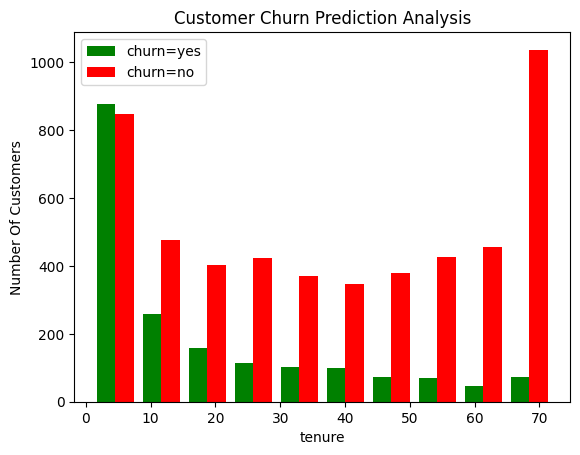

In [96]:
tenure_churn_no = df1[df1.Churn=='No'].tenure
tenure_churn_yes = df1[df1.Churn=='Yes'].tenure

plt.xlabel("tenure")
plt.ylabel("Number Of Customers")
plt.title("Customer Churn Prediction Analysis")
plt.legend()

plt.hist([tenure_churn_yes, tenure_churn_no], color=['green', 'red'], label=['churn=yes', 'churn=no'])
plt.legend()

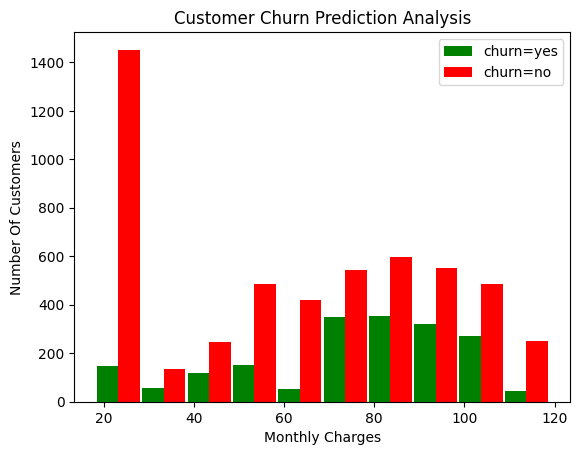

In [97]:
mc_churn_no = df1[df1.Churn=='No'].MonthlyCharges
mc_churn_yes = df1[df1.Churn=='Yes'].MonthlyCharges

plt.xlabel("Monthly Charges")
plt.ylabel("Number Of Customers")
plt.title("Customer Churn Prediction Analysis")


blood_sugar_men = [113,85,90,150,149,88,93,115,135,80,77,82,129]
blood_sugar_women = [67,98,89,120,133,150,84,69,89,79,120,112,100]

plt.hist([mc_churn_yes, mc_churn_no],rwidth=0.95, color=['green', 'red'], label=['churn=yes', 'churn=no'])
plt.legend()



### **Problem:** Visualizing the distribution of `MonthlyCharges` for churned vs. non-churned customers

Similar to `tenure`, `MonthlyCharges` is another key numerical feature that could influence customer churn. Understanding its distribution for churned versus non-churned customers can help identify if higher or lower monthly charges correlate with a higher likelihood of churn.

### **Solution:** Plotting histograms for `MonthlyCharges` by churn status

This cell filters `df1` to create two Series: `mc_churn_no` (monthly charges for non-churned customers) and `mc_churn_yes` (monthly charges for churned customers). It then uses `matplotlib.pyplot.hist()` to generate a histogram comparing the `MonthlyCharges` distributions of these two groups. Using different colors and a legend (green for no churn, red for yes churn) provides a visual insight into whether certain monthly charge ranges are more prevalent among customers who churn or stay.

In [98]:
for column in df:
  print(column)

gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


### **Problem:** Identifying categorical columns for further preprocessing

Before encoding categorical features, it's essential to identify all columns that are of `object` (string) type, as these are typically the categorical columns that require conversion. Additionally, we need to inspect the unique values within each of these columns to understand their cardinality and structure, which helps in deciding the appropriate encoding strategy (e.g., binary encoding, one-hot encoding).

### **Solution:** Defining and using a helper function to print unique object column values

This cell defines a helper function `print_unique_col_values(df)` that iterates through each column in a DataFrame. If a column's data type is `object`, it prints the column name and all its unique values. This function is then called with `df1` to get a quick summary of all categorical columns and their distinct values. This output is crucial for identifying 'Yes'/'No' columns, columns with more than two unique values that need one-hot encoding, and identifying inconsistent values like 'No internet service' or 'No phone service' that need to be standardized.

In [99]:
def print_unique_col_values(df):
  for column in df:
    if df[column].dtypes=='object':
      print(f'{column}: {df[column].unique()}')

In [ ]:
def print_unique_col_values(df): # Define a function to print unique values of object type columns
  for column in df:
    if df[column].dtypes=='object': # Check if the column's data type is 'object' (typically strings)
      print(f'{column}: {df[column].unique()}') # Print the column name and its unique values

In [100]:
print_unique_col_values(df1)

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


In [ ]:
print_unique_col_values(df1) # Call the helper function to display unique values for all object columns in df1

In [101]:
df1.replace('No internet service', 'No', inplace=True)
df1.replace('No phone service', 'No', inplace=True)

/tmp/ipykernel_2392/4245438437.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.replace('No internet service', 'No', inplace=True)
/tmp/ipykernel_2392/4245438437.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.replace('No phone service', 'No', inplace=True)


In [ ]:
df1.replace('No internet service', 'No', inplace=True) # Replace 'No internet service' with 'No' across the DataFrame
df1.replace('No phone service', 'No', inplace=True) # Replace 'No phone service' with 'No' across the DataFrame

### **Problem:** Standardizing 'No internet service' and 'No phone service' entries

Upon inspecting the unique values of categorical columns, it was observed that columns like `MultipleLines`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, and `StreamingMovies` contain three distinct values: 'Yes', 'No', and 'No internet service' or 'No phone service'. For machine learning models, it's more appropriate to represent 'No internet service' or 'No phone service' as simply 'No', as it implies the absence of that service. This standardization simplifies encoding and reduces the number of unique categories.

### **Solution:** Replacing 'No internet service' and 'No phone service' with 'No'

This cell uses the `replace()` method on `df1` to substitute all occurrences of 'No internet service' with 'No' and 'No phone service' with 'No'. The `inplace=True` argument ensures that the changes are made directly to the DataFrame. After these replacements, the `print_unique_col_values()` function is called again to verify that the standardization has been successful, and these columns now only contain 'Yes' and 'No' (or 'No phone service' will be 'No').

In [102]:
print_unique_col_values(df1)


gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes']
OnlineBackup: ['Yes' 'No']
DeviceProtection: ['No' 'Yes']
TechSupport: ['No' 'Yes']
StreamingTV: ['No' 'Yes']
StreamingMovies: ['No' 'Yes']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


In [ ]:
print_unique_col_values(df1) # Verify the unique values after replacement

In [103]:
yes_no_columns = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']

for col in yes_no_columns:
  df1[col].replace({'Yes':1, 'No':0}, inplace=True)


/tmp/ipykernel_2392/3058007921.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1[col].replace({'Yes':1, 'No':0}, inplace=True)
/tmp/ipykernel_2392/3058007921.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1[col].replace({'Yes':1, 'No':0}, inplace=True)
/tmp/ipykernel_2392/3058007921.py:

In [ ]:
yes_no_columns = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn'] # Define a list of binary 'Yes'/'No' columns

for col in yes_no_columns:
  df1[col].replace({'Yes':1, 'No':0}, inplace=True) # Replace 'Yes' with 1 and 'No' with 0 in these columns

### **Problem:** Converting binary categorical columns to numeric (0s and 1s)

Many categorical columns in our dataset have only two unique values, typically 'Yes' and 'No' (or 'Female'/'Male'). Machine learning algorithms require numerical input, so these binary categorical features need to be converted into a numerical representation, usually 0s and 1s. This process is called binary encoding.

### **Solution:** Iterating and replacing 'Yes'/'No' with 1/0

This cell first defines a list `yes_no_columns` containing the names of all columns that are binary and currently have 'Yes'/'No' values (including the target variable `Churn`). It then iterates through this list, and for each column, it uses the `replace()` method to map 'Yes' to 1 and 'No' to 0. The `inplace=True` argument applies these changes directly to the `df1` DataFrame. After this, `print_unique_col_values(df1)` is called to confirm that these columns now contain only 0s and 1s, and other object-type columns are untouched.

In [104]:
for col in df1:
  print(f'{col}: {df1[col].unique()}')

gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: [1 0]
Dependents: [0 1]
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
PhoneService: [0 1]
MultipleLines: [0 1]
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: [0 1]
OnlineBackup: [1 0]
DeviceProtection: [0 1]
TechSupport: [0 1]
StreamingTV: [0 1]
StreamingMovies: [0 1]
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: [1 0]
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges: [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges: [  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ]
Churn: [0 1]


In [ ]:
for col in df1: # Iterate through all columns in df1
  print(f'{col}: {df1[col].unique()}') # Print unique values for each column to verify changes

In [105]:
df1['gender'].replace({'Female':1, 'Male':0}, inplace=True)

/tmp/ipykernel_2392/3951318906.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['gender'].replace({'Female':1, 'Male':0}, inplace=True)
/tmp/ipykernel_2392/3951318906.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1['gender'].replace({'Female':1, 'Male':0}, inplace=True)
/tmp/ipykernel

In [ ]:
df1['gender'].replace({'Female':1, 'Male':0}, inplace=True) # Replace 'Female' with 1 and 'Male' with 0 in the 'gender' column

### **Problem:** Converting the 'gender' column to numeric

The 'gender' column is a binary categorical feature with 'Female' and 'Male' values. Similar to the 'Yes'/'No' columns, it needs to be converted into a numerical representation (0s and 1s) for machine learning models to process.

### **Solution:** Replacing 'Female' and 'Male' with 1 and 0

This cell specifically targets the 'gender' column. It uses the `replace()` method to map 'Female' to 1 and 'Male' to 0. The `inplace=True` argument ensures the change is applied directly to the `df1` DataFrame. Afterwards, `df1['gender'].unique()` is called to verify that the column now contains only 0s and 1s, confirming the successful numerical encoding of the gender information.

In [106]:
df1['gender'].unique()

array([1, 0])

In [ ]:
df1['gender'].unique() # Display unique values of the 'gender' column to confirm conversion

In [107]:
df2 = pd.get_dummies(data=df1,columns=['InternetService', 'Contract', 'PaymentMethod'])

# Convert boolean columns to int (0s and 1s)
for col in df2.columns:
    if df2[col].dtype == 'bool':
        df2[col] = df2[col].astype(int)

df2.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [ ]:
df2 = pd.get_dummies(data=df1,columns=['InternetService', 'Contract', 'PaymentMethod']) # Apply one-hot encoding to specified categorical columns

# Convert boolean columns to int (0s and 1s)
for col in df2.columns:
    if df2[col].dtype == 'bool': # Check if the column's data type is boolean
        df2[col] = df2[col].astype(int) # Convert boolean (True/False) to integer (1/0)

df2.columns # Display the new column names after one-hot encoding

### **Problem:** Handling multi-category nominal features using one-hot encoding

Columns like `InternetService`, `Contract`, and `PaymentMethod` are categorical but have more than two unique values (multi-category nominal features). Direct numerical encoding (e.g., 0, 1, 2) would imply an ordinal relationship which doesn't exist. To properly represent these features for machine learning models, one-hot encoding is required. This process creates new binary columns for each category, indicating the presence or absence of that category.

### **Solution:** Applying `pd.get_dummies` and converting boolean columns to integers

This cell uses `pd.get_dummies()` to perform one-hot encoding on the specified columns (`InternetService`, `Contract`, `PaymentMethod`). This function creates new columns with binary values (True/False or 1/0) for each unique category within the original columns, effectively converting them into a numerical format. The `data=df1` argument specifies the DataFrame to encode, and `columns` lists the columns to be transformed. After `pd.get_dummies` creates boolean columns, a loop iterates through `df2` and converts any boolean columns to integers (0 or 1) to ensure consistency and compatibility with the machine learning model. Finally, `df2.columns` is displayed to show the newly created one-hot encoded columns and all other features ready for modeling.

In [108]:
df.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4691,Female,1,Yes,No,56,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),100.65,5688.05,Yes
4557,Male,0,No,No,53,No,No phone service,DSL,No,No,Yes,Yes,Yes,Yes,One year,No,Credit card (automatic),54.90,3045.75,No
6253,Female,0,No,No,56,No,No phone service,DSL,No,No,No,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),44.85,2564.95,No
3346,Female,1,No,No,2,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,84.05,186.05,No
1736,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.50,19.5,Yes


In [ ]:
df2.dtypes # Display the data types of all columns in df2 to confirm numerical conversion

### **Problem:** Confirming data types after extensive preprocessing

After numerous preprocessing steps—handling missing values, converting binary categorical features, and applying one-hot encoding to multi-category features—it's crucial to verify that all columns intended for the machine learning model are now in a numerical format. Inconsistent data types can lead to errors during model training or incorrect model behavior.

### **Solution:** Displaying the data types of all columns in `df2`

This cell simply calls `df2.dtypes` to display the data type of every column in the `df2` DataFrame. This serves as a final check to ensure that all features are indeed numerical (int64 or float64) and ready for the next stages of the machine learning pipeline, such as feature scaling and model training. Any remaining `object` type columns would indicate an overlooked preprocessing step.

In [109]:
df2.dtypes

,0
gender,int64
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
MultipleLines,int64
OnlineSecurity,int64
OnlineBackup,int64
DeviceProtection,int64


In [ ]:
cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges'] # Define a list of numerical columns to be scaled

from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler for feature scaling
scaler = MinMaxScaler() # Create an instance of MinMaxScaler
df2[cols_to_scale] = scaler.fit_transform(df2[cols_to_scale]) # Apply Min-Max scaling to the selected columns in df2

### **Problem:** Scaling numerical features

Machine learning algorithms, especially those based on gradient descent (like neural networks), often perform better and converge faster when numerical input features are scaled to a similar range. Features with larger values can dominate the learning process, leading to suboptimal model performance. Standardization or normalization helps address this issue.

### **Solution:** Applying MinMaxScaler to selected numerical columns

This cell identifies the numerical columns `tenure`, `MonthlyCharges`, and `TotalCharges` that need scaling. It then imports `MinMaxScaler` from `sklearn.preprocessing`, which scales features to a given range, typically 0 to 1. An instance of the scaler is created, and `scaler.fit_transform()` is applied to the selected columns of `df2`. This method first computes the minimum and maximum values for each column (`fit`) and then scales the data accordingly (`transform`), overwriting the original values in `df2`. This ensures all numerical features are within a consistent range, improving model training stability and performance.

In [110]:
cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df2[cols_to_scale] = scaler.fit_transform(df2[cols_to_scale])

In [ ]:
df2.sample(3) # Display 3 random rows from df2 to visually inspect the scaled numerical features

### **Problem:** Inspecting scaled features

After applying `MinMaxScaler`, it's important to quickly inspect a sample of the DataFrame to confirm that the selected numerical columns (`tenure`, `MonthlyCharges`, `TotalCharges`) have indeed been scaled to a range between 0 and 1. This visual check helps ensure the scaling process was successful and the data is transformed as expected.

### **Solution:** Displaying a sample of the DataFrame

This cell uses `df2.sample(3)` to display 3 random rows from the `df2` DataFrame. By observing the values in the `tenure`, `MonthlyCharges`, and `TotalCharges` columns, we can visually confirm that their values now fall within the 0 to 1 range, indicating successful Min-Max scaling. This quick check helps to prevent potential issues in subsequent model training due to incorrectly scaled features.

In [111]:
df2.sample(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3938,1,0,0,0,0.014085,1,0,1,0,0,...,1,0,0,1,0,0,0,0,0,1
1285,0,1,1,0,0.084507,1,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0
4979,1,0,1,1,0.774648,1,1,0,0,0,...,0,0,1,0,0,1,0,0,0,1


### **Problem:** Verifying unique values across all columns after scaling

After scaling numerical features and performing all previous preprocessing steps, it's a good practice to re-check the unique values of all columns. This ensures that no unintended changes occurred and that all features (both numerical and encoded categorical) are in their expected ranges or representations (e.g., 0s and 1s).

### **Solution:** Printing unique values for every column

This cell iterates through all columns in the `df2` DataFrame and prints the unique values for each. For the scaled numerical columns, this will show a range of float values. For the binary encoded and one-hot encoded categorical columns, it should show only 0s and 1s. This comprehensive check helps confirm the integrity and readiness of the entire dataset for model input.

In [112]:
for col in df2:
  print(f'{col}: {df2[col].unique()}')

gender: [1 0]
SeniorCitizen: [0 1]
Partner: [1 0]
Dependents: [0 1]
tenure: [0.         0.46478873 0.01408451 0.61971831 0.09859155 0.29577465
 0.12676056 0.38028169 0.85915493 0.16901408 0.21126761 0.8028169
 0.67605634 0.33802817 0.95774648 0.71830986 0.98591549 0.28169014
 0.15492958 0.4084507  0.64788732 1.         0.22535211 0.36619718
 0.05633803 0.63380282 0.14084507 0.97183099 0.87323944 0.5915493
 0.1971831  0.83098592 0.23943662 0.91549296 0.11267606 0.02816901
 0.42253521 0.69014085 0.88732394 0.77464789 0.08450704 0.57746479
 0.47887324 0.66197183 0.3943662  0.90140845 0.52112676 0.94366197
 0.43661972 0.76056338 0.50704225 0.49295775 0.56338028 0.07042254
 0.04225352 0.45070423 0.92957746 0.30985915 0.78873239 0.84507042
 0.18309859 0.26760563 0.73239437 0.54929577 0.81690141 0.32394366
 0.6056338  0.25352113 0.74647887 0.70422535 0.35211268 0.53521127]
PhoneService: [0 1]
MultipleLines: [0 1]
OnlineSecurity: [0 1]
OnlineBackup: [1 0]
DeviceProtection: [0 1]
TechSupport: [

In [ ]:
for col in df2:
  print(f'{col}: {df2[col].unique()}') # Print unique values for each column in df2 to verify the final state of all features

In [113]:
x = df2.drop('Churn', axis='columns')
y = df2['Churn']

In [ ]:
x = df2.drop('Churn', axis='columns') # Create feature set 'x' by dropping the 'Churn' column
y = df2['Churn'] # Create target variable 'y' from the 'Churn' column

### **Problem:** Separating features (X) from the target variable (y)

For supervised machine learning, it's essential to clearly separate the input features (independent variables) from the target variable (dependent variable) that the model will predict. In this customer churn prediction task, 'Churn' is our target variable, and all other columns are features.

### **Solution:** Dropping the 'Churn' column for features and assigning it to the target

This cell creates two new DataFrames: `x` and `y`. `x` is created by dropping the 'Churn' column from `df2` using `df2.drop('Churn', axis='columns')`. The `axis='columns'` argument specifies that a column is being dropped. `y` is created by simply selecting the 'Churn' column from `df2`. This clear separation prepares the data for the next step: splitting into training and testing sets.

In [80]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=5)

In [ ]:
from sklearn.model_selection import train_test_split # Import train_test_split function
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=5) # Split data into training and testing sets (80% train, 20% test, with a fixed random state)

### **Problem:** Splitting data into training and testing sets

To evaluate the performance of a machine learning model, it's crucial to train it on one subset of the data and test it on a separate, unseen subset. This helps in assessing how well the model generalizes to new data and avoids overfitting. A common split is 80% for training and 20% for testing.

### **Solution:** Using `train_test_split` from `sklearn.model_selection`

This cell imports `train_test_split` from `sklearn.model_selection`. It then uses this function to divide the feature set `x` and target variable `y` into training (`x_train`, `y_train`) and testing (`x_test`, `y_test`) sets. `test_size=0.2` specifies that 20% of the data will be used for testing, and `random_state=5` ensures reproducibility of the split, meaning the same split will be generated every time the code is run. This setup is fundamental for robust model evaluation.

In [114]:
x_train.shape


(5625, 26)

In [ ]:
x_train.shape # Display the shape (number of rows, number of columns) of the training feature set

### **Problem:** Verifying the shape of training and testing sets

After splitting the data into training and testing sets, it's good practice to quickly check the dimensions (number of rows and columns) of these new sets. This ensures that the split occurred as expected and that the sets have the correct number of samples and features.

### **Solution:** Displaying the `.shape` attribute of `x_train` and `x_test`

This cell simply calls `x_train.shape` and `x_test.shape` to print the dimensions of the training and testing feature sets, respectively. This confirms that the number of samples corresponds to the 80/20 split and that the number of features matches the original `x` DataFrame, providing confidence that the data is correctly prepared for model input.

In [115]:
x_test.shape

(1407, 26)

In [ ]:
x_test.shape # Display the shape of the testing feature set

In [116]:
x_train[:10]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
5664,1,1,0,0,0.126761,1,0,0,0,1,...,0,1,0,1,0,0,0,1,0,0
101,1,0,1,1,0.000000,1,0,0,0,0,...,0,0,1,1,0,0,0,0,1,0
2621,0,0,1,0,0.985915,1,0,0,1,1,...,1,0,0,0,0,1,0,1,0,0
392,1,1,0,0,0.014085,1,0,0,0,0,...,1,0,0,1,0,0,0,0,1,0
1327,0,0,1,0,0.816901,1,1,0,0,1,...,0,1,0,0,1,0,1,0,0,0
3607,1,0,0,0,0.169014,1,0,1,0,0,...,1,0,0,0,1,0,0,0,0,1
2773,0,0,1,0,0.323944,0,0,0,0,1,...,1,0,0,1,0,0,0,0,1,0
1936,1,0,1,0,0.704225,1,0,1,1,0,...,1,0,0,0,1,0,1,0,0,0
5387,0,0,0,0,0.042254,0,0,0,0,0,...,1,0,0,1,0,0,0,0,1,0
4331,0,0,0,0,0.985915,1,1,0,0,0,...,0,0,1,0,0,1,1,0,0,0


In [ ]:
x_train[:10] # Display the first 10 rows of the training feature set for inspection

### **Problem:** Inspecting the training features

Before feeding the training data into a neural network, it's helpful to take a quick look at the first few rows of the training feature set (`x_train`). This provides a visual confirmation of the data's format, ensuring that all features are numerical and scaled correctly.

### **Solution:** Displaying the first 10 rows of `x_train`

This cell simply prints `x_train[:10]` to display the first 10 rows of the training feature set. This allows for a visual inspection of the feature values, confirming that they are all numerical (0s, 1s, and scaled float values) as expected after all the preprocessing steps.

In [117]:
len(x_train.columns)

26

In [ ]:
len(x_train.columns) # Get the number of columns (features) in the training data, which will be the input shape for the neural network

### **Problem:** Determining the input shape for the neural network

When defining the input layer of a neural network, especially with Keras, you need to specify the `input_shape`. This corresponds to the number of features in a single sample of your input data. Knowing the exact number of features in `x_train` is crucial for correctly configuring the neural network architecture.

### **Solution:** Getting the number of columns in `x_train`

This cell uses `len(x_train.columns)` to determine the total number of features (columns) in the `x_train` DataFrame. This value (26 in this case) will be used as the `input_shape` for the first `Dense` layer in the Keras model, ensuring that the network is correctly initialized to accept our prepared input data.

In [118]:
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Dense(20, input_shape=(26,), activation='relu'),
    # keras.layers.Dense(15, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=50)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7685 - loss: 0.5018
Epoch 2/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7927 - loss: 0.4334
Epoch 3/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8011 - loss: 0.4217
Epoch 4/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8036 - loss: 0.4175
Epoch 5/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8036 - loss: 0.4146
Epoch 6/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8037 - loss: 0.4130
Epoch 7/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8068 - loss: 0.4108
Epoch 8/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8071 - loss: 0.4098
Epoch 9/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8080 - loss: 0.4088
Epoch 10/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8066 - loss: 0.4082
Epoch 11/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8087 - loss: 0.4074
Epoch 12/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy

In [ ]:
import tensorflow as tf # Import TensorFlow library
from tensorflow import keras # Import Keras from TensorFlow

# Define the neural network model
model = keras.Sequential([
    keras.layers.Dense(20, input_shape=(26,), activation='relu'), # Input layer with 20 neurons, ReLU activation, and input shape of 26 features
    # keras.layers.Dense(15, activation='relu'), # An optional hidden layer (commented out)
    keras.layers.Dense(1, activation='sigmoid') # Output layer with 1 neuron and Sigmoid activation for binary classification
])

# Compile the model
model.compile(optimizer='adam', # Use the Adam optimizer
              loss='binary_crossentropy', # Use binary cross-entropy as the loss function for binary classification
              metrics=['accuracy']) # Monitor accuracy during training

# Train the model
model.fit(x_train, y_train, epochs=50) # Train the model on x_train and y_train for 50 epochs

### **Problem:** Building, compiling, and training a neural network model

To predict customer churn, a neural network model needs to be defined, configured (compiled), and then trained on the preprocessed training data. The model should be capable of handling binary classification and learning the underlying patterns that lead to churn.

### **Solution:** Defining a Keras Sequential model, compiling with Adam optimizer, and training for 50 epochs

This cell first imports `tensorflow` and `keras`. It then defines a `keras.Sequential` model: an input `Dense` layer with 20 neurons and `relu` activation (taking `26` input features as determined earlier), and an output `Dense` layer with 1 neuron and `sigmoid` activation (suitable for binary classification, outputting a probability between 0 and 1). The model is then `compile`d with the `adam` optimizer, `binary_crossentropy` loss function (standard for binary classification), and `accuracy` as the metric to monitor. Finally, `model.fit()` trains the model using `x_train` and `y_train` for 50 `epochs`, iteratively adjusting the model's weights to minimize the loss and improve accuracy.

In [120]:
model.evaluate(x_test, y_test)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7889 - loss: 0.4430


[0.44296592473983765, 0.7889125943183899]

In [ ]:
model.evaluate(x_test, y_test) # Evaluate the trained model's performance on the test data

### **Problem:** Evaluating the trained model's performance on unseen data

After training the neural network, it's essential to assess its performance on data it has not seen before (the test set). This provides an unbiased estimate of how well the model will generalize to new, real-world customer data.

### **Solution:** Using `model.evaluate()` on the test set

This cell calls `model.evaluate(x_test, y_test)` to calculate the loss and accuracy of the trained model on the `x_test` features and `y_test` true labels. The output will show the test loss and test accuracy, which are key metrics to understand the model's generalization capability. A high test accuracy and low test loss indicate good model performance.

In [121]:
yp = model.predict(x_test)
yp[:5]

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


array([[0.19822134],
       [0.4192196 ],
       [0.00976707],
       [0.790872  ],
       [0.581047  ]], dtype=float32)

In [ ]:
yp = model.predict(x_test) # Get probability predictions for the test data
yp[:5] # Display the first 5 probability predictions

### **Problem:** Obtaining predictions from the trained model

To calculate classification metrics like precision, recall, and F1-score, we first need to get the model's predictions on the test dataset. The output of the sigmoid activation function in our model is a probability score between 0 and 1, representing the likelihood of churn.

### **Solution:** Using `model.predict()` to get probability predictions

This cell calls `model.predict(x_test)` to generate probability predictions for each sample in the `x_test` set. The `yp` variable will store an array of these probabilities. Displaying `yp[:5]` shows the first 5 predicted probabilities, which are continuous values between 0 and 1. These probabilities will subsequently be converted into binary class labels (0 or 1) for classification reporting.

In [125]:
y_test[:10]

,Churn
2660,0
744,0
5579,1
64,1
3287,1
816,1
2670,0
5920,0
1023,0
6087,0


In [ ]:
y_test[:10] # Display the first 10 true churn labels from the test set

### **Problem:** Inspecting true labels from the test set

To compare the model's predictions with the actual outcomes, it's useful to inspect the true labels (`y_test`) from the test dataset. This provides a direct reference for understanding what the model should have predicted.

### **Solution:** Displaying the first 10 true labels

This cell simply prints `y_test[:10]` to display the first 10 true churn labels from the `y_test` Series. This allows for a quick comparison with the model's initial predictions and helps in understanding the context for subsequent classification report analysis.

In [126]:
y_pred = []
for element in yp:
  if element > 0.5:
    y_pred.append(1)
  else:
    y_pred.append(0)

In [ ]:
y_pred = [] # Initialize an empty list to store binary predictions
for element in yp: # Iterate through each predicted probability
  if element > 0.5: # If the probability is greater than 0.5, classify as churn (1)
    y_pred.append(1)
  else: # Otherwise, classify as no churn (0)
    y_pred.append(0)

### **Problem:** Converting probability predictions to binary class labels

The neural network outputs probabilities for churn (values between 0 and 1). For classification tasks, these probabilities need to be converted into discrete class labels (0 for no churn, 1 for churn). This requires setting a threshold.

### **Solution:** Applying a 0.5 threshold to predictions

This cell initializes an empty list `y_pred`. It then iterates through each probability `element` in the `yp` (predicted probabilities) array. If a probability is greater than 0.5, it's classified as 1 (churn); otherwise, it's classified as 0 (no churn). These binary labels are appended to `y_pred`. This process converts the continuous probability outputs into discrete class predictions, which are necessary for calculating classification metrics.

In [127]:
y_pred[:10]

[0, 0, 0, 1, 1, 1, 0, 1, 0, 0]

In [ ]:
y_pred[:10] # Display the first 10 binary predictions

### **Problem:** Inspecting the converted binary predictions

After converting the model's probability outputs into binary class labels (0s and 1s), it's useful to quickly inspect the first few of these labels. This verifies that the conversion process worked as intended and that we have discrete predictions ready for evaluation.

### **Solution:** Displaying the first 10 binary predictions

This cell simply prints `y_pred[:10]` to display the first 10 binary class predictions. This allows for a quick visual check of the converted output, confirming that they are indeed 0s or 1s, which are essential for comparing against the true labels and generating classification reports.

In [130]:
# classification report

from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86       999
           1       0.67      0.54      0.60       408

    accuracy                           0.79      1407
   macro avg       0.75      0.72      0.73      1407
weighted avg       0.78      0.79      0.78      1407



### **Problem:** Comprehensive evaluation of classification model performance

Accuracy alone is often insufficient for evaluating classification models, especially with imbalanced datasets. More detailed metrics like precision, recall, and F1-score provide a deeper understanding of the model's strengths and weaknesses for each class. A confusion matrix visually summarizes these results.

### **Solution:** Generating and displaying a classification report and confusion matrix

This cell first imports `confusion_matrix` and `classification_report` from `sklearn.metrics`. `classification_report(y_test, y_pred)` then generates a text-based report that includes precision, recall, F1-score, and support for both classes (0 and 1). This report is printed to the console. Next, a confusion matrix (`cm`) is created using `tf.math.confusion_matrix(labels=y_test, predictions=y_pred)`. This matrix shows the counts of true positives, true negatives, false positives, and false negatives. Finally, `seaborn.heatmap()` is used to visualize this confusion matrix with annotations, making it easy to interpret the model's classification performance graphically, highlighting where the model succeeded and where it made errors.

Text(95.72222222222221, 0.5, 'Truth')

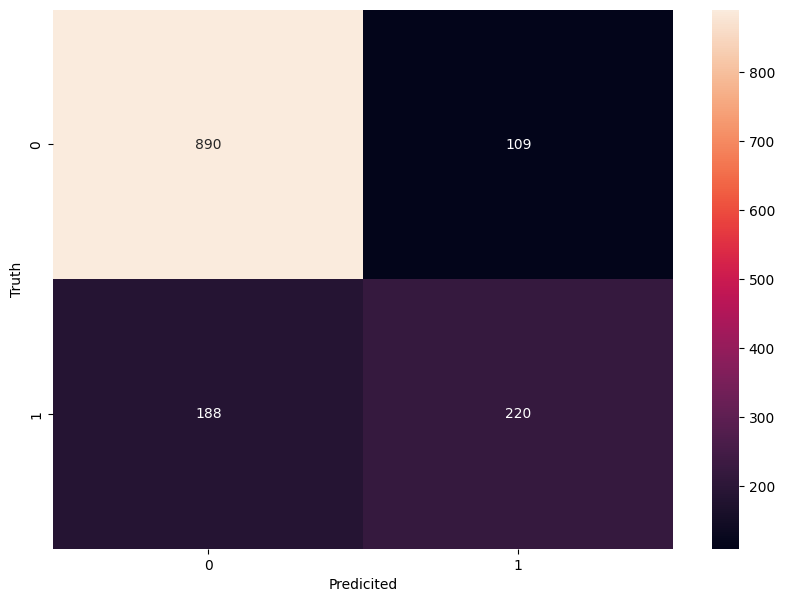

In [131]:
import seaborn as sn
cm = tf.math.confusion_matrix(labels=y_test, predictions=y_pred)

plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicited')
plt.ylabel('Truth')

### **Problem:** Calculating overall accuracy from the confusion matrix

The confusion matrix provides raw counts of correct and incorrect predictions. To derive the overall accuracy, we need to sum the correctly predicted instances (true positives + true negatives) and divide by the total number of instances. This confirms the accuracy reported by `model.evaluate()` and `classification_report`.

### **Solution:** Manual calculation of accuracy from confusion matrix values

This cell performs a manual calculation of accuracy based on the counts observed in the confusion matrix (890 true negatives, 220 true positives, 109 false positives, 188 false negatives). The formula `(True Negatives + True Positives) / (True Negatives + True Positives + False Positives + False Negatives)` is applied. The `round(..., 2)` function formats the result to two decimal places, providing a clear and interpretable accuracy score derived directly from the confusion matrix.

when the truth is 1 which means when in my excel file, when we say customer is leaving , 220 it predicted 1 but 188 when the truth wa 1 it predicted 0, which means this was an error..Anything which is in diagonal si correct pred..and anything which is not in a diagonal is error

Accuracy


In [134]:
round((890+220)/(890+220+109+188), 2)

0.79

In [ ]:
round((890+220)/(890+220+109+188), 2) # Manually calculate overall accuracy from confusion matrix values

precesion for the 0 class i.e Precision for customers who did not churn

### **Problem:** Calculating precision for the 'no churn' class (class 0)

Precision for a specific class (here, customers who did not churn, class 0) measures the proportion of correctly predicted positive instances out of all instances predicted as positive for that class. In other words, it answers: "Of all customers we predicted would not churn, how many actually did not churn?"

### **Solution:** Manual calculation of precision for class 0 from confusion matrix

This cell calculates the precision for class 0 using the confusion matrix values: `True Negatives / (True Negatives + False Negatives)`. From our confusion matrix, 890 were correctly predicted as no churn (True Negatives), and 188 were incorrectly predicted as no churn (False Negatives). The `round(..., 2)` function formats the result to two decimal places, providing the precision score for the 'no churn' class.

In [135]:
round(890/(890+188), 2)

0.83

In [ ]:
round(890/(890+188), 2) # Manually calculate precision for class 0 (no churn) from confusion matrix

precision for 1 class i.e, Precision for customers who actually churned

### **Problem:** Calculating precision for the 'churn' class (class 1)

Precision for the 'churn' class (class 1) is a crucial metric, as it indicates how reliable the model's positive predictions are. It measures the proportion of correctly predicted churn instances out of all instances the model predicted would churn. In simpler terms: "Of all customers we predicted would churn, how many actually churned?"

### **Solution:** Manual calculation of precision for class 1 from confusion matrix

This cell calculates the precision for class 1 using the confusion matrix values: `True Positives / (True Positives + False Positives)`. From our confusion matrix, 220 were correctly predicted as churn (True Positives), and 109 were incorrectly predicted as churn (False Positives). The `round(..., 2)` function formats the result to two decimal places, providing the precision score for the 'churn' class.

In [136]:
round(220/(220+109), 2)

0.67

In [ ]:
round(220/(220+109), 2) # Manually calculate precision for class 1 (churn) from confusion matrix

recall for 0 class

### **Problem:** Calculating recall for the 'no churn' class (class 0)

Recall for a specific class (here, customers who did not churn, class 0) measures the proportion of actual positive instances that were correctly identified by the model. In other words, it answers: "Of all customers who actually did not churn, how many did the model correctly identify as not churning?"

### **Solution:** Manual calculation of recall for class 0 from confusion matrix

This cell calculates the recall for class 0 using the confusion matrix values: `True Negatives / (True Negatives + False Positives)`. From our confusion matrix, 890 were correctly predicted as no churn (True Negatives), and 109 were incorrectly predicted as churn (False Positives, meaning they were actually no-churn but predicted as churn). The `round(..., 2)` function formats the result to two decimal places, providing the recall score for the 'no churn' class.

In [138]:
round(890/(890+109), 2)

0.89

In [ ]:
round(890/(890+109), 2) # Manually calculate recall for class 0 (no churn) from confusion matrix

In [139]:
round(220/(220+188), 2)

0.54

In [ ]:
round(220/(220+188), 2) # Manually calculate recall for class 1 (churn) from confusion matrix

### **Problem:** Calculating recall for the 'churn' class (class 1)

Recall for the 'churn' class (class 1) is particularly important in churn prediction, as it measures the model's ability to identify all actual churners. It is the proportion of actual positive instances (customers who churned) that were correctly identified by the model. In simpler terms: "Of all customers who actually churned, how many did the model correctly identify as churning?"

### **Solution:** Manual calculation of recall for class 1 from confusion matrix

This cell calculates the recall for class 1 using the confusion matrix values: `True Positives / (True Positives + False Negatives)`. From our confusion matrix, 220 were correctly predicted as churn (True Positives), and 188 were actual churners but incorrectly predicted as no churn (False Negatives). The `round(..., 2)` function formats the result to two decimal places, providing the recall score for the 'churn' class.